In [201]:
import numpy as np
import matplotlib.pyplot as plt

In [202]:
X = np.array([
    [0, 0], 
    [0, 1],
    [1, 0], 
    [1, 1]])

y = np.array([0, 0, 0, 1])

In [203]:
w1 = np.random.rand()
w2 = np.random.rand()
b = np.zeros(1)

In [204]:
def step_function(z):
  if z >= 0:
    return 1
  return 0

In [205]:
lr = 0.1
epochs = 10

In [206]:
for epoch in range(epochs):
  for i in range(len(X)):
    z = w1 * X[i][0] + w2 * X[i][1] + b
    y_pred = step_function(z)

    error = y[i] - y_pred

    w1 += lr * error * X[i][0]
    w2 += lr * error * X[i][1]
    b += lr * error
print("Weight 1:", w1)
print("Weight 2:", w2)
print("Bias:", b)

Weight 1: 0.3849717663430833
Weight 2: 0.29037719860348576
Bias: [-0.4]


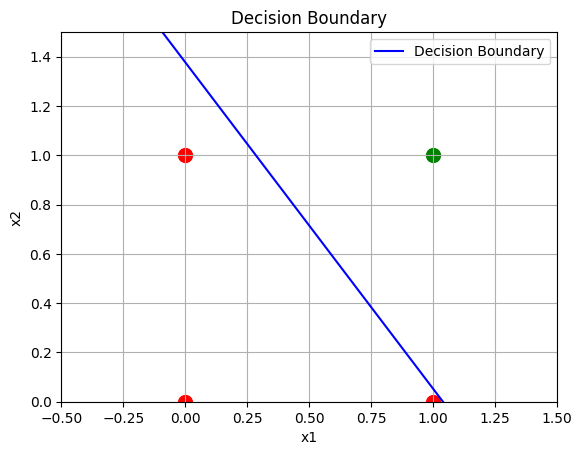

In [207]:
import matplotlib.pyplot as plt
    
w = np.array([w1, w2])
# Plot data points
for i in range(len(X)):
    if y[i] == 0:
        plt.scatter(X[i][0], X[i][1], color='red', s=100)
    else:
        plt.scatter(X[i][0], X[i][1], color='green', s=100)

# Decision boundary: w0*x1 + w1*x2 + b = 0
x_vals = np.array([-0.5, 1.5])

if w[1] != 0:
    y_vals = -(w[0] * x_vals + b) / w[1]
    plt.plot(x_vals, y_vals, 'b-', label='Decision Boundary')
else:
    plt.axvline(x=-b / w[0], color='blue', label='Decision Boundary')

plt.xlim(-0.5, 1.5)
plt.ylim(-0, 1.5)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Decision Boundary")
plt.grid(True)
plt.legend()

plt.show()

In [208]:
class Perceptron:

    def __init__(self, input_size, lr = 0.1, epochs = 10) -> None:
        self.w = np.random.rand(input_size)
        self.b = 0.0
        self.lr = lr
        self.epochs = epochs

    def step_function(self, z) -> int:
        return 1 if z >= 0 else 0

    def forward(self, x) -> int:
        a = np.dot(x, self.w) + self.b
        return self.step_function(a)

    def fit(self, X, y) -> None:
        for epoch in range(self.epochs):
            for i in range(len(X)):
                y_pred = self.forward(X[i])

                error = y[i] - y_pred

                
                self.w += self.lr * error * X[i]
                self.b += self.lr * error

In [209]:
perceptron = Perceptron(2, 0.1, 10)
perceptron.fit(X, y)

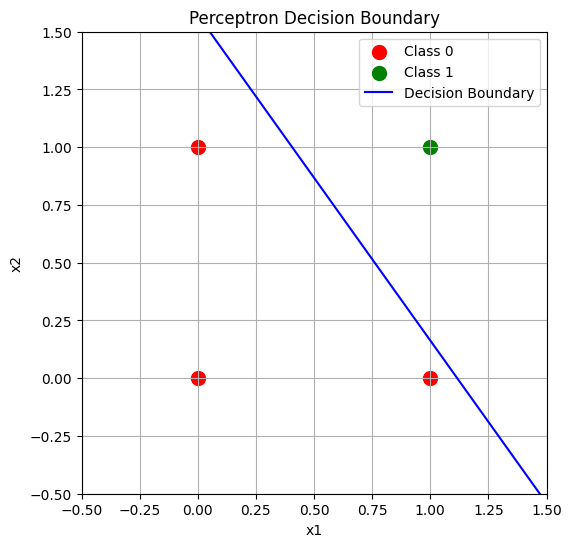

In [210]:
plt.figure(figsize=(6, 6))
for i in range(len(X)):
    if y[i] == 0:
        plt.scatter(X[i][0], X[i][1], color="red", s=100, label="Class 0" if i == 0 else "")
    else:
        plt.scatter(X[i][0], X[i][1], color="green", s=100, label="Class 1" if i == 3 else "")

# 4. Extract weights and plot decision boundary
w = perceptron.w
b = perceptron.b

x_vals = np.array([-0.5, 1.5])

if w[1] != 0:
    y_vals = -(w[0] * x_vals + b) / w[1]
    plt.plot(x_vals, y_vals, "b-", label="Decision Boundary")
else:
    plt.axvline(x=-b / w[0], color="blue", label="Decision Boundary")

plt.xlim(-0.5, 1.5)
plt.ylim(-0.5, 1.5)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Perceptron Decision Boundary")
plt.grid(True)
plt.legend()
plt.show()